# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [27]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [28]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [29]:
# !mkdir -p data
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

In [30]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


In [31]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


In [32]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

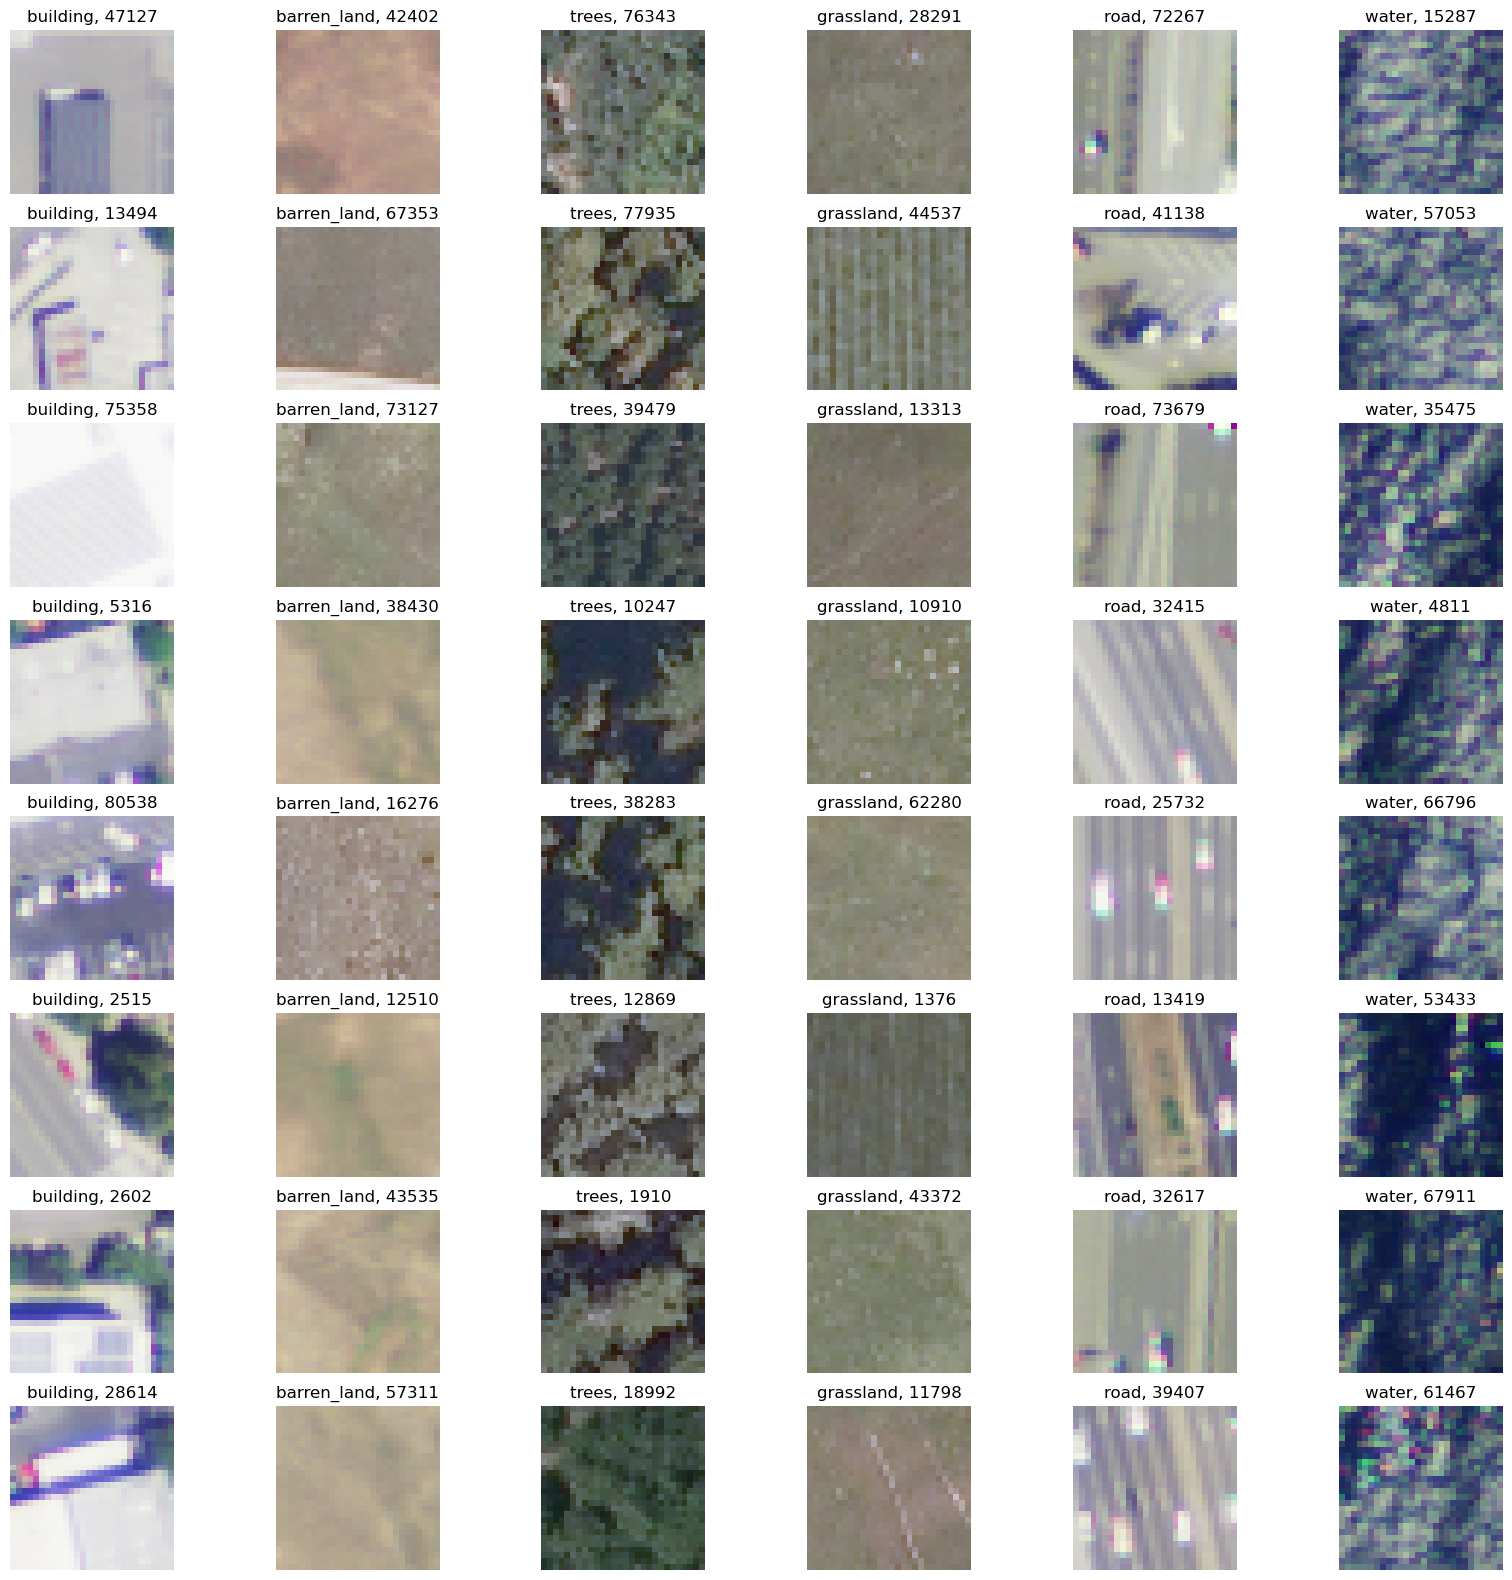

In [33]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [34]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


In [35]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

In [36]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
17516,76,98,83,12,57,82,81,8,32,48,...,76,7,22,45,74,5,31,46,76,6
56250,237,239,233,175,230,229,228,158,225,229,...,247,230,248,248,247,230,247,247,247,229
45734,193,192,207,107,196,177,213,112,180,159,...,192,90,193,193,191,89,190,191,191,86
14398,126,149,113,101,92,111,96,54,84,94,...,194,142,183,189,183,129,181,186,180,122
4928,130,127,144,35,122,125,141,37,143,141,...,165,91,192,187,168,81,169,163,160,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,185,174,148,174,189,176,151,177,193,186,...,152,195,196,185,157,190,205,190,159,185
47957,165,156,126,163,159,152,129,163,152,149,...,138,166,176,157,136,164,174,161,137,160
69640,103,113,93,186,93,93,43,172,118,128,...,64,73,50,48,53,62,51,56,61,59
73376,122,119,113,151,84,83,75,135,91,94,...,115,149,138,131,123,154,140,133,123,153


## Define and intialize random classifier from scikit-learn

In [37]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [38]:
rf.fit( train_X, train_y)

RandomForestClassifier()

## Check the prediction on the test set

In [39]:
rf.score(test_X, test_y)

0.9216666666666666

# Task 2.2

Evaluate the classification accuracy of each class and to plot a small number of correct classification examples and a small number of misclassifications

In [51]:
y_pred = rf.predict(test_X)

true_class = np.argmax(test_y.values, axis=1)
pred_class = np.argmax(y_pred, axis=1)

acc_per_class = {}
for i, column in enumerate(labels):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], pred_class[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

building: 0.9200
barren_land: 0.9400
trees: 0.9800
grassland: 0.8500
road: 0.8800
water: 0.9900


In [52]:
print(y_pred)

[[0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 ...
 [0 0 0 0 1 0]
 [0 0 0 0 1 0]
 [0 0 1 0 0 0]]


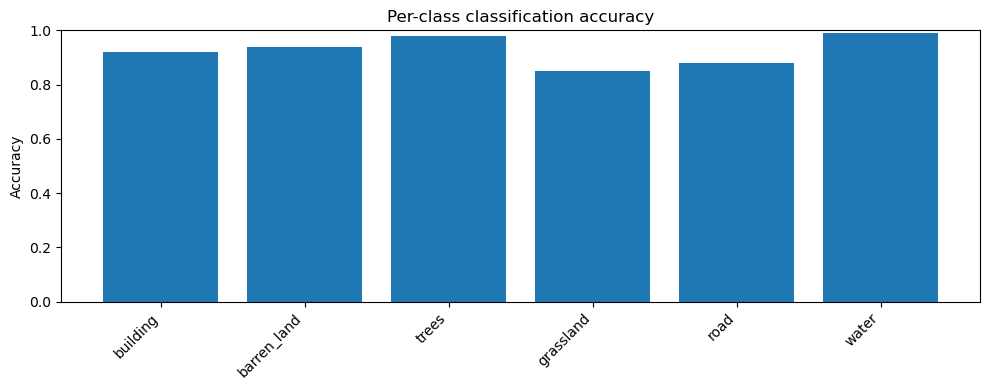

In [53]:
# plot the per-class accuracy 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acc_per_class.keys(), acc_per_class.values())
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Per-class classification accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

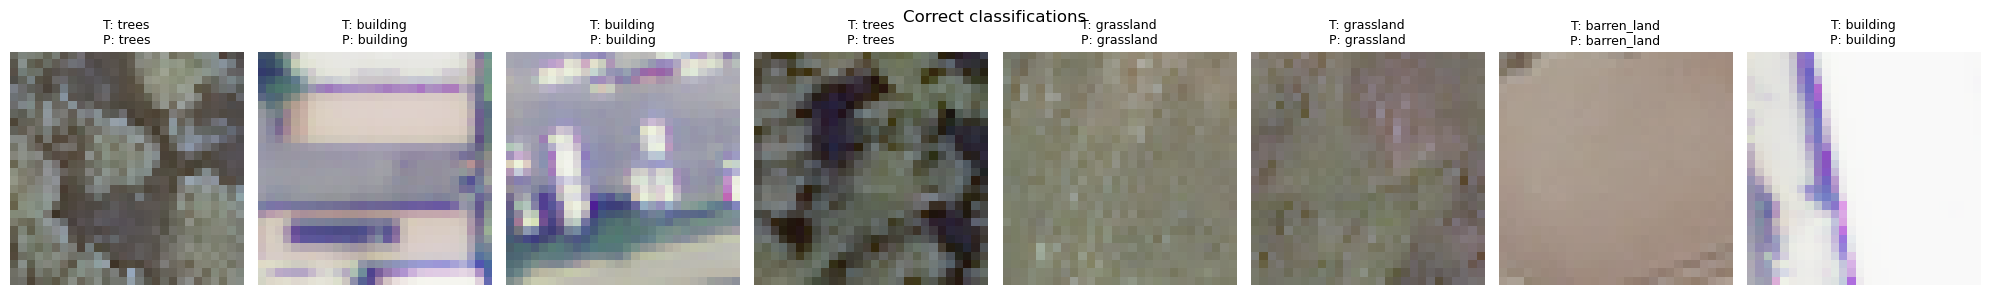

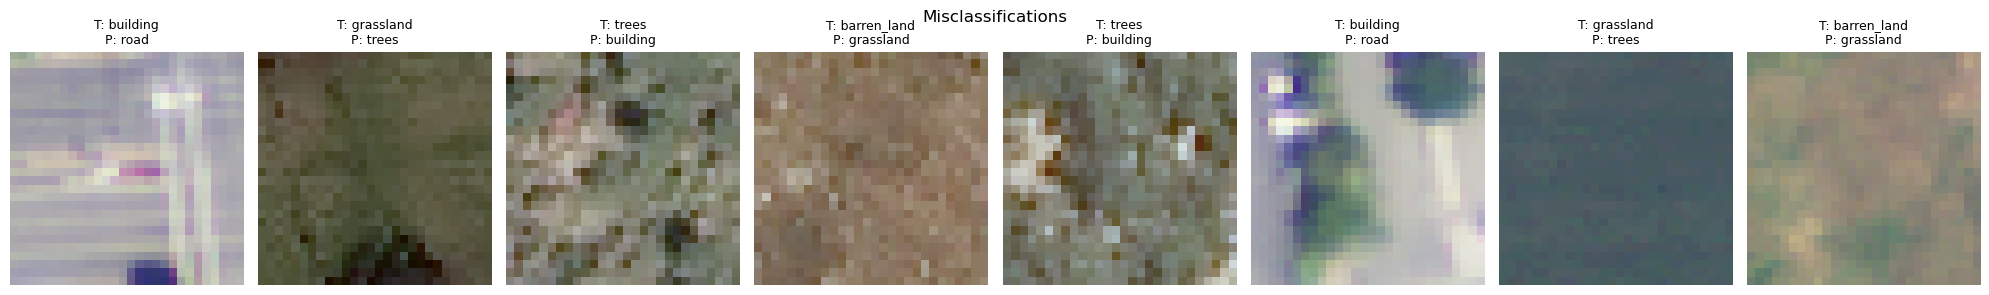

In [42]:
true_class = np.argmax(test_y.values, axis=1)
pred_class = np.argmax(y_pred, axis=1)
correct_mask = pred_class == true_class
incorrect_mask = ~correct_mask
correct_positions = np.where(correct_mask)[0]
incorrect_positions = np.where(incorrect_mask)[0]
num_examples = 8  # number of examples to display per row

# Randomly pick examples
rng = np.random.default_rng()
 
# randomly pick a number of unique samples where predicited and true class match as well as differs
# size=min(num_examples, ...) ensures that even if fewer than num_examples unique samples exists the code is not crashing
# replace = False means without repetition

correct_pick = rng.choice(
    correct_positions,
    size=min(num_examples, len(correct_positions)),
    replace=False
)
incorrect_pick = rng.choice(
    incorrect_positions,
    size=min(num_examples, len(incorrect_positions)),
    replace=False
)

# plot the samples 
def plot_examples(positions, title):
    n = len(positions)
    fig, ax = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1:
        ax = [ax]
    for k, pos in enumerate(positions):
        # Reconstruct the image from the flat feature vector
        img = np.reshape(test_X.iloc[pos].values, (-1, 28, 28, 4))
        ax[k].imshow(img[0, ..., :3])
        ax[k].axis('off')
        true_name = str(labels[true_class[pos]])
        pred_name = str(labels[pred_class[pos]])
        ax[k].set_title(f"T: {true_name}\nP: {pred_name}", fontsize=9)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
plot_examples(correct_pick, "Correct classifications")
plot_examples(incorrect_pick, "Misclassifications")

# Task 2.3

Inspect the 4 color channels of the data (R, G, B, and NIR). Modify the code so that it only uses the R, G, and B channels. 

In [43]:
# Extract images and labels corresponding to the selected indices
# Reshape to (n, 28, 28, 4), drop NIR channel, flatten back to 2D
train_X_rgb = landcover_df.iloc[train_idx].values.reshape(-1, 28, 28, 4)[..., :3].reshape(len(train_idx), -1)
train_y = labels_df.iloc[train_idx]
test_X_rgb = landcover_df.iloc[test_idx].values.reshape(-1, 28, 28, 4)[..., :3].reshape(len(test_idx), -1)
test_y = labels_df.iloc[test_idx]

rf_rgb = RandomForestClassifier(n_estimators=100)
rf_rgb.fit(train_X_rgb, train_y)
rf_rgb.score(test_X_rgb, test_y)

0.8866666666666667

In [56]:
y_pred_rgb = rf_rgb.predict(test_X_rgb)
#print(y_pred)
true_class = np.argmax(test_y.values, axis=1)
pred_class = np.argmax(y_pred_rgb, axis=1)
acc_per_class = {}

for i,column in enumerate(labels):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], pred_class[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

building: 0.9700
barren_land: 0.9100
trees: 0.9200
grassland: 0.7700
road: 0.8600
water: 0.9900


# Task 2.4

Make use of only R, G, and NIR.

In [45]:
# Reshape to (n, 28, 28, 4), drop Blue channel, keep R, G, NIR, flatten back
train_X_rgnir = landcover_df.iloc[train_idx].values.reshape(-1, 28, 28, 4)[..., [0, 1, 3]].reshape(len(train_idx), -1)
train_y = labels_df.iloc[train_idx]
test_X_rgnir = landcover_df.iloc[test_idx].values.reshape(-1, 28, 28, 4)[..., [0, 1, 3]].reshape(len(test_idx), -1)
test_y = labels_df.iloc[test_idx]

rf_rgnir = RandomForestClassifier(n_estimators=100)
rf_rgnir.fit(train_X_rgnir, train_y)
rf_rgnir.score(test_X_rgnir, test_y)

0.91

In [57]:
y_pred_rgnir = rf_rgnir.predict(test_X_rgnir)
#print(y_pred)

true_class = np.argmax(test_y.values, axis=1)
pred_class = np.argmax(y_pred_rgnir, axis=1)

acc_per_class = {}

for i,column in enumerate(labels):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], pred_class[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

building: 0.9200
barren_land: 0.9300
trees: 0.9700
grassland: 0.8000
road: 0.9000
water: 1.0000


# Task 2.5

Look at the documentation of RF and its hyper parameters. Choose one and modify its value.

In [47]:
rf_md = RandomForestClassifier(
    n_estimators=100,
    max_depth=15 # chosen hyperparameter
)

rf_md.fit(train_X, train_y)
rf_md.score(test_X, test_y)

0.915

In [48]:
depths = [1, 5, 10, 15, 20, 25, 30, 50, 100, None]

results = []

for d in depths:
    rf_md = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
    )
    
    rf_md.fit(train_X, train_y)
    acc = rf_md.score(test_X, test_y)
    
    results.append((d, acc))
    print(f"max_depth={d}: accuracy={acc:.4f}")

max_depth=1: accuracy=0.1617
max_depth=5: accuracy=0.7833
max_depth=10: accuracy=0.9000
max_depth=15: accuracy=0.9067
max_depth=20: accuracy=0.9133
max_depth=25: accuracy=0.9183
max_depth=30: accuracy=0.9183
max_depth=50: accuracy=0.9133
max_depth=100: accuracy=0.9117
max_depth=None: accuracy=0.9133


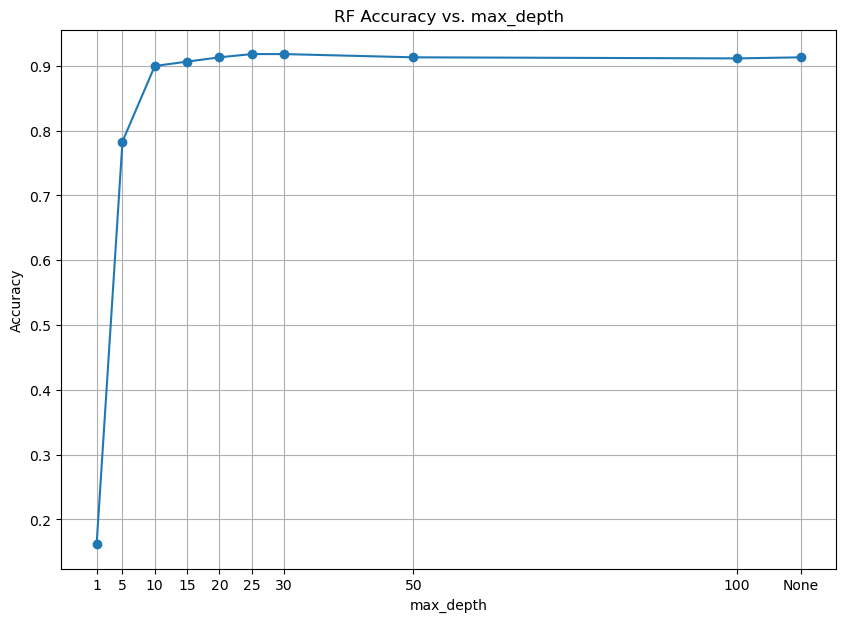

In [49]:
# plot the accuracy of our rf classifier for each vlaue of max_depth
depth_values = [d if d is not None else 110 for d, acc in results]
accuracy_values = [acc for d, acc in results]
x_labels = [str(d) if d is not None else "None" for d, acc in results]

plt.figure(figsize=(10,7))
plt.plot(depth_values, accuracy_values, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("RF Accuracy vs. max_depth")
plt.xticks(depth_values, x_labels)

plt.grid(True)
plt.show()